# Applied Data Science Project
## Financial Distress and ESG Performance Analysis

**Team members:**
- COULIBALY Mamakan: 95812376
- MBELLA Jackson nils bryan: 97757044
- COULIBALY Vanomo:  2947521
- AAMOUD Aicha:  91601932
- EZZAHER Aymane: 97423225
---

## 0. Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

## 1. Data Loading

In [2]:
financial = pd.read_csv('data/financial_data.csv')
incidents = pd.read_csv('data/reprisk_risk_incidents.csv')
universe  = pd.read_csv('data/reprisk_universe.csv')

In [3]:
incidents.head(5)

,reprisk_id,story_id,incident_date,severity,reach,environment,social,governance,company_name,primary_isin
0,10,958325,26aug2019,2,1,T,T,F,Acer Inc,TW0002353000
1,10,315135,11apr2018,2,1,T,T,F,Acer Inc,TW0002353000
2,10,3299340,12dec2020,2,1,F,T,F,Acer Inc,TW0002353000
3,10,8182305,15oct2021,1,2,F,T,F,Acer Inc,TW0002353000
4,10,1717750,02mar2020,1,1,F,T,F,Acer Inc,TW0002353000


In [4]:
print(incidents.info())
print(incidents.describe())
print(incidents.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321722 entries, 0 to 321721
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   reprisk_id     321722 non-null  int64 
 1   story_id       321722 non-null  int64 
 2   incident_date  321722 non-null  object
 3   severity       321722 non-null  int64 
 4   reach          321722 non-null  int64 
 5   environment    321722 non-null  object
 6   social         321722 non-null  object
 7   governance     321722 non-null  object
 8   company_name   321722 non-null  object
 9   primary_isin   130717 non-null  object
dtypes: int64(4), object(6)
memory usage: 24.5+ MB
None
         reprisk_id      story_id       severity          reach
count  3.217220e+05  3.217220e+05  321722.000000  321722.000000
mean   4.956847e+05  3.058668e+06       1.298556       1.678278
std    7.416407e+05  3.057226e+06       0.496653       0.639170
min    2.000000e+00  2.127480e+05       1.000000 

In [5]:
universe.head(5)

,primary_isin,year
0,US44973Q1031,2020
1,US44973Q1031,2018
2,US44973Q1031,2021
3,US44973Q1031,2019
4,US75678V3024,2021


In [6]:
print(universe.info())
print(universe.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20652 entries, 0 to 20651
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   primary_isin  20652 non-null  object
 1   year          20652 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 322.8+ KB
None
primary_isin    0
year            0
dtype: int64


In [7]:
financial.head(5)

,cusip,year,conm,act,at,ebit,lct,lt,re,sale,mktcap,sic
0,46603210,2017,J & J SNACK FOODS CORP,381.832,867.228,116.307,119.044,184.906,664.940,1084.224,2834.362500,2050.0
1,46603210,2018,J & J SNACK FOODS CORP,382.797,932.013,110.775,117.899,172.922,731.751,1138.265,2714.532500,2050.0
2,46603210,2019,J & J SNACK FOODS CORP,506.357,1019.339,116.956,121.234,185.588,788.007,1186.487,3482.703100,2050.0
3,46603210,2020,J & J SNACK FOODS CORP,499.557,1056.553,27.157,134.126,247.055,760.230,1022.038,2945.193600,2050.0
4,29402E10,2017,ENVELA CORP,10.892,13.315,1.984,5.559,5.559,-32.686,61.995,25.083933,5990.0


In [8]:
print(financial.info())
print(financial.describe())
print(financial.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17279 entries, 0 to 17278
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   cusip   17279 non-null  object 
 1   year    17279 non-null  int64  
 2   conm    17279 non-null  object 
 3   act     11916 non-null  float64
 4   at      15517 non-null  float64
 5   ebit    15466 non-null  float64
 6   lct     11935 non-null  float64
 7   lt      15494 non-null  float64
 8   re      15122 non-null  float64
 9   sale    15467 non-null  float64
 10  mktcap  17279 non-null  float64
 11  sic     15445 non-null  float64
dtypes: float64(9), int64(1), object(2)
memory usage: 1.6+ MB
None
               year            act            at           ebit  \
count  17279.000000   11916.000000  1.551700e+04   15466.000000   
mean    2018.496383    1880.180690  1.212374e+04     535.174921   
std        1.121136    7964.341417  8.706146e+04    2829.587240   
min     2017.000000       0.004000  2.

## 2. Pre-processing

### 2.1 Parse incident dates and extract year

We convert the `incident_date` column to datetime format and extract the year. We then restrict the data to 2018–2021 to match the RepRisk universe coverage.

In [9]:
# Convert date + extract year
incidents['incident_date'] = pd.to_datetime(incidents['incident_date'], format='%d%b%Y', errors='coerce')
incidents['year'] = incidents['incident_date'].dt.year

# Keep only 2018-2021
incidents = incidents[incidents['year'].between(2018, 2021)].copy()

print(f'Incidents from 2018 to 2021: {len(incidents):,}')
print(incidents[['incident_date', 'year']].head(5))

Incidents from 2018 to 2021: 321,722
  incident_date  year
0    2019-08-26  2019
1    2018-04-11  2018
2    2020-12-12  2020
3    2021-10-15  2021
4    2020-03-02  2020


In [10]:
# Convert ESG columns: 'T' → 1, else → 0
# Note: we use strict equality (== 'T') to avoid matching strings that contain 'T' as a substring
for col in ['environment', 'social', 'governance']:
    incidents[col] = (incidents[col].str.strip() == 'T').astype(int)

print(incidents[['environment', 'social', 'governance']].head(5))

   environment  social  governance
0            1       1           0
1            1       1           0
2            0       1           0
3            0       1           0
4            0       1           0


A quick look at ESG indicator distribution shows that social and governance incidents are more frequent than environmental ones.

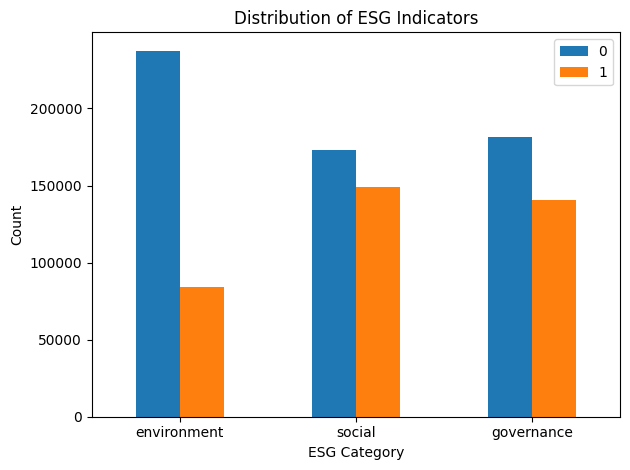

In [11]:
counts = incidents[['environment', 'social', 'governance']].apply(lambda x: x.value_counts())
counts.T.plot(kind='bar')
plt.title('Distribution of ESG Indicators')
plt.xlabel('ESG Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.2 Compute ESG scores per firm-year

We compute a weighted score using `severity × reach` to capture the importance of each incident, not just its count. We also keep a simple count score for robustness checks.

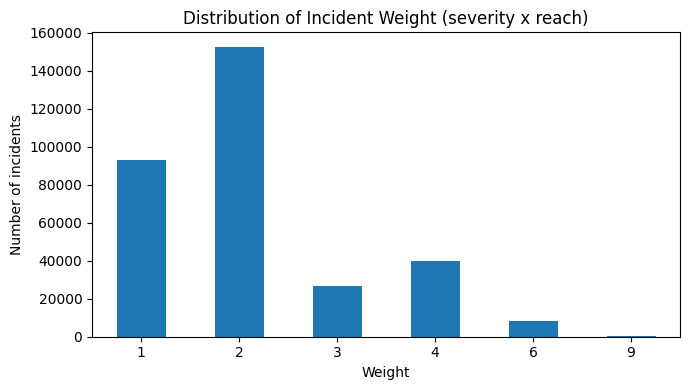

In [12]:
# Weight = severity × reach
incidents['weight'] = incidents['severity'] * incidents['reach']

plt.figure(figsize=(7, 4))
incidents['weight'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Incident Weight (severity x reach)')
plt.xlabel('Weight')
plt.ylabel('Number of incidents')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
# Weighted scores at incident level
incidents['e_weight_score'] = incidents['environment'] * incidents['weight']
incidents['s_weight_score'] = incidents['social']      * incidents['weight']
incidents['g_weight_score'] = incidents['governance']  * incidents['weight']

# Count scores (for robustness)
incidents['e_count_score'] = incidents['environment']
incidents['s_count_score'] = incidents['social']
incidents['g_count_score'] = incidents['governance']

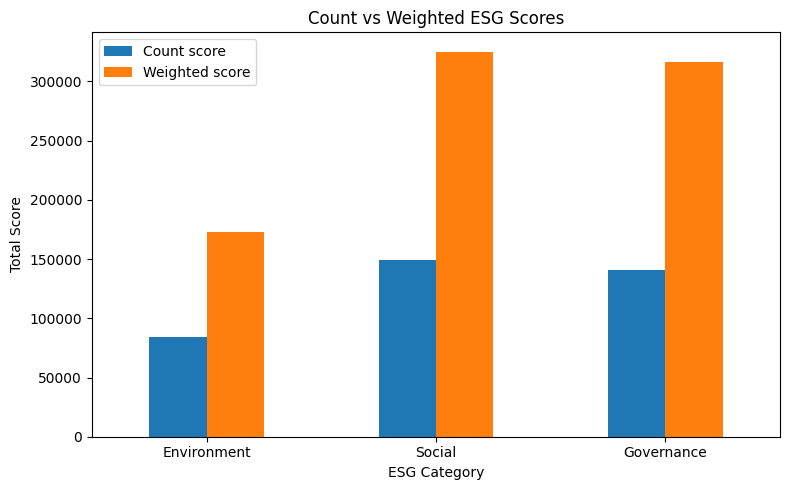

In [14]:
# Compare count vs weighted totals
count_scores  = incidents[['e_count_score',  's_count_score',  'g_count_score']].sum()
weight_scores = incidents[['e_weight_score', 's_weight_score', 'g_weight_score']].sum()

comparison = pd.DataFrame({
    'Count score':    count_scores.values,
    'Weighted score': weight_scores.values
}, index=['Environment', 'Social', 'Governance'])

comparison.plot(kind='bar', figsize=(8, 5))
plt.title('Count vs Weighted ESG Scores')
plt.xlabel('ESG Category')
plt.ylabel('Total Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
# Keep only US firms (ISIN starts with 'US')
us_incidents = incidents[incidents['primary_isin'].str.startswith('US', na=False)].copy()

print(f'Total incidents: {len(incidents):,}')
print(f'US incidents   : {len(us_incidents):,}')

Total incidents: 321,722
US incidents   : 41,504


In [16]:
# Aggregate to firm-year level
esg_agg = us_incidents.groupby(['primary_isin', 'year']).agg(
    n_incidents    = ('story_id',       'count'),
    e_weight_score = ('e_weight_score', 'sum'),
    s_weight_score = ('s_weight_score', 'sum'),
    g_weight_score = ('g_weight_score', 'sum'),
    e_count_score  = ('e_count_score',  'sum'),
    s_count_score  = ('s_count_score',  'sum'),
    g_count_score  = ('g_count_score',  'sum'),
).reset_index()

print(f'Firm-year ESG observations: {len(esg_agg):,}')
esg_agg.head()

Firm-year ESG observations: 7,066


,primary_isin,year,n_incidents,e_weight_score,s_weight_score,g_weight_score,e_count_score,s_count_score,g_count_score
0,US0003071083,2019,1,0,2,0,0,1,0
1,US0003071083,2021,1,0,2,0,0,1,0
2,US0003611052,2021,1,1,1,0,1,1,0
3,US00081T1088,2021,2,0,0,0,0,0,0
4,US00090Q1031,2020,2,0,4,0,0,2,0


In [17]:
# Total ESG scores
esg_agg['esg_weight_score'] = (
    esg_agg['e_weight_score'] +
    esg_agg['s_weight_score'] +
    esg_agg['g_weight_score']
)
esg_agg['esg_count_score'] = esg_agg['n_incidents']

print(esg_agg[['esg_count_score', 'esg_weight_score']].mean())

esg_count_score      5.873762
esg_weight_score    15.687235
dtype: float64


### 2.3 RepRisk universe merge

We merge with the RepRisk universe to include firms with zero incidents. Any missing values after the merge represent firm-years with no recorded ESG incidents, so we fill them with 0.

In [18]:
# Keep US firms from universe
us_universe = universe[universe['primary_isin'].str.startswith('US', na=False)].copy()

print(f'US firm-years in universe: {len(us_universe):,}')
print(us_universe['year'].value_counts().sort_index())

US firm-years in universe: 20,652
2018    5163
2019    5163
2020    5163
2021    5163
Name: year, dtype: int64


In [19]:
# Merge with ESG scores (right join on universe)
esg_full = us_universe.merge(esg_agg, on=['primary_isin', 'year'], how='left')

print(f'After ESG merge: {len(esg_full):,}')
esg_full.head()

After ESG merge: 20,652


,primary_isin,year,n_incidents,e_weight_score,s_weight_score,g_weight_score,e_count_score,s_count_score,g_count_score,esg_weight_score,esg_count_score
0,US44973Q1031,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,US44973Q1031,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,US44973Q1031,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,US44973Q1031,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,US75678V3024,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# Fill NaN with 0 (firms in universe with no incidents)
score_cols = [
    'n_incidents',
    'e_weight_score', 's_weight_score', 'g_weight_score',
    'e_count_score',  's_count_score',  'g_count_score',
    'esg_weight_score', 'esg_count_score'
]
esg_full[score_cols] = esg_full[score_cols].fillna(0)

print(f'Firm-years with 0 incidents: {(esg_full["n_incidents"] == 0).sum():,}')

Firm-years with 0 incidents: 13,586


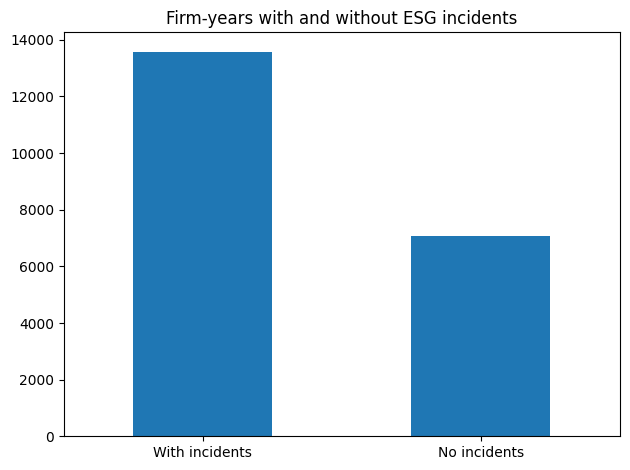

In [21]:
(esg_full['n_incidents'] == 0).value_counts().plot(kind='bar')
plt.title('Firm-years with and without ESG incidents')
plt.xticks([0, 1], ['With incidents', 'No incidents'], rotation=0)
plt.tight_layout()
plt.show()

### 2.4 Link ISIN and CUSIP, then merge financial data

US ISIN structure: `US` + 8-char CUSIP + 1 check digit → `ISIN[2:10]` = CUSIP (8 chars)

In [22]:
# Extract CUSIP from ISIN
financial['cusip8'] = financial['cusip'].astype(str).str.zfill(8)
esg_full['cusip8']  = esg_full['primary_isin'].str[2:10]

In [23]:
fin = financial.copy()

# Working capital
fin['WC'] = fin['act'] - fin['lct']

# Remove rows with missing or zero total assets / liabilities
fin = fin[(fin['at'] > 0) & (fin['lt'] > 0)]

print(fin[['WC', 'at', 'lt']].head())

        WC        at       lt
0  262.788   867.228  184.906
1  264.898   932.013  172.922
2  385.123  1019.339  185.588
3  365.431  1056.553  247.055
4    5.333    13.315    5.559


In [24]:
# Altman Z-score formula
fin['zscore'] = (
    1.2 * (fin['WC']     / fin['at']) +
    1.4 * (fin['re']     / fin['at']) +
    3.3 * (fin['ebit']   / fin['at']) +
    0.6 * (fin['mktcap'] / fin['lt']) +
    1.0 * (fin['sale']   / fin['at'])
)

fin = fin.dropna(subset=['zscore'])
fin[['conm', 'year', 'zscore']].head(5)

,conm,year,zscore
0,J & J SNACK FOODS CORP,2017,12.327056
1,J & J SNACK FOODS CORP,2018,12.472578
2,J & J SNACK FOODS CORP,2019,14.337735
3,J & J SNACK FOODS CORP,2020,9.627276
4,ENVELA CORP,2017,4.899005


In [25]:
print(fin['zscore'].describe())

count    11530.000000
mean         9.161349
std        465.594520
min       -464.220166
25%          0.963800
50%          2.633537
75%          5.006463
max      49871.422018
Name: zscore, dtype: float64


In [26]:
# Classify firms into Z-score zones
def zscore_zone(z):
    if z < 1.81:
        return 'Distress'
    elif z <= 2.99:
        return 'Grey'
    else:
        return 'Safe'

fin['zscore_zone'] = fin['zscore'].apply(zscore_zone)

print(fin['zscore_zone'].value_counts())

Safe        5197
Distress    4363
Grey        1970
Name: zscore_zone, dtype: int64


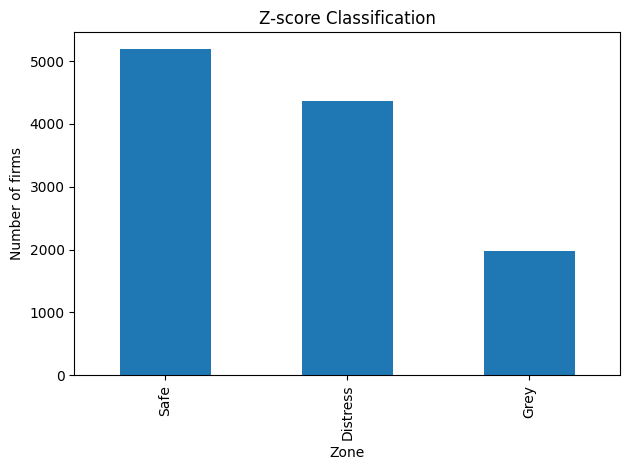

In [27]:
fin['zscore_zone'].value_counts().plot(kind='bar')
plt.title('Z-score Classification')
plt.xlabel('Zone')
plt.ylabel('Number of firms')
plt.tight_layout()
plt.show()

In [28]:
# Check extreme values (before winsorizing)
lower = fin['zscore'].quantile(0.01)
upper = fin['zscore'].quantile(0.99)
extreme = ((fin['zscore'] < lower) | (fin['zscore'] > upper)).sum()

print(f'Lower bound (1st pct) : {lower:.2f}')
print(f'Upper bound (99th pct): {upper:.2f}')
print(f'Extreme values        : {extreme:,}  ({extreme/len(fin):.2%})')

Lower bound (1st pct) : -31.97
Upper bound (99th pct): 62.93
Extreme values        : 232  (2.01%)


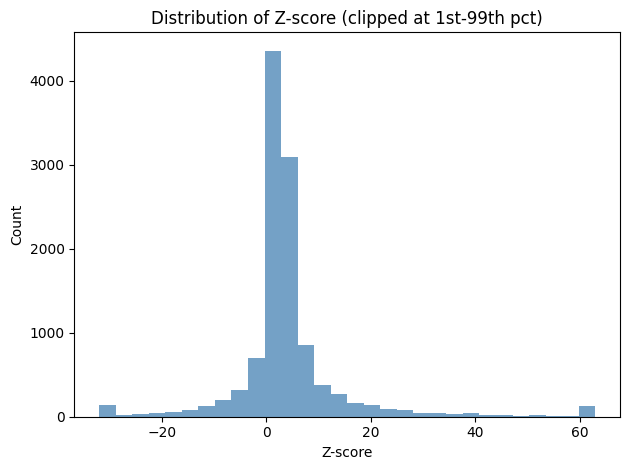

In [29]:
plt.hist(fin['zscore'].clip(lower, upper), bins=30, color='steelblue', alpha=0.75)
plt.title('Distribution of Z-score (clipped at 1st-99th pct)')
plt.xlabel('Z-score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [30]:
# Lag financials by 1 year: financial data year t explains ESG year t+1
fin_lag = fin.copy()
fin_lag['year'] = fin_lag['year'] + 1

# Merge
df = esg_full.merge(
    fin_lag[['cusip8', 'year', 'conm', 'zscore', 'zscore_zone',
             'WC', 'at', 're', 'ebit', 'mktcap', 'lt', 'sale', 'sic',
             'act', 'lct']],
    on=['cusip8', 'year'],
    how='inner'
)

print(f'After financial merge: {len(df):,} firm-year observations')
df.head(3)

After financial merge: 5,927 firm-year observations


,primary_isin,year,n_incidents,e_weight_score,s_weight_score,g_weight_score,e_count_score,s_count_score,g_count_score,esg_weight_score,...,WC,at,re,ebit,mktcap,lt,sale,sic,act,lct
0,US69327R1014,2021,1.0,1.0,1.0,0.0,1.0,1.0,0.0,2.0,...,-471.609,5237.973,-772.265,-613.007,2047.2722,2622.435,1339.226,1311.0,308.248,779.857
1,US69327R1014,2020,7.0,10.0,2.0,2.0,7.0,1.0,1.0,14.0,...,-57.200,4448.680,-47.945,56.076,1612.5168,2113.173,1156.123,1311.0,304.030,361.230
2,US69327R1014,2019,5.0,6.0,4.0,3.0,4.0,3.0,1.0,13.0,...,-166.554,4544.145,8.727,78.140,1967.2253,2017.437,1548.659,1311.0,274.460,441.014


### 2.5 Drop financial and utility firms

In [31]:
n_before = len(df)

# Drop financials (SIC 6000-6999) and utilities (SIC 4900-4999)
df = df[~df['sic'].between(6000, 6999)]
df = df[~df['sic'].between(4900, 4999)]

# Drop rows with missing z-score
df = df.dropna(subset=['zscore'])

print(f'Dropped financials & utilities: {n_before - len(df):,} rows')
print(f'Final dataset: {len(df):,} firm-year observations')
print(f'Unique firms : {df["primary_isin"].nunique():,}')
print(f'Years covered: {sorted(df["year"].unique())}')

Dropped financials & utilities: 556 rows
Final dataset: 5,371 firm-year observations
Unique firms : 1,520
Years covered: [2018, 2019, 2020, 2021]


## 3. Descriptive Statistics & Distributions

### 3.1 Summary statistics

In [32]:
desc_cols = ['esg_weight_score', 'e_weight_score', 's_weight_score', 'g_weight_score',
             'zscore', 'at', 'sale', 'mktcap', 'WC']
df[desc_cols].describe().round(3)

,esg_weight_score,e_weight_score,s_weight_score,g_weight_score,zscore,at,sale,mktcap,WC
count,5371.00,5371.000,5371.000,5371.000,5371.000,5371.000,5371.000,5371.000,5371.000
mean,10.88,2.317,5.324,3.239,13.204,11192.988,8306.451,16370.013,970.456
std,44.09,11.885,23.160,14.404,680.513,33741.820,26944.500,69337.836,5204.687
min,0.00,0.000,0.000,0.000,-131.660,0.714,0.000,1.434,-18857.000
25%,0.00,0.000,0.000,0.000,1.481,719.398,565.032,635.253,42.583
50%,0.00,0.000,0.000,0.000,2.797,2335.000,1848.959,2362.144,255.328
75%,5.00,0.000,2.000,1.000,4.458,7276.731,5631.918,9080.184,770.812
max,1095.00,289.000,645.000,336.000,49871.422,551669.000,556933.000,2232278.800,117462.000


### 3.2 Distribution plots

We plot the distribution of our main variables. ESG scores are heavily right-skewed (most firms have zero incidents). The Z-score is also skewed with extreme values, which justifies winsorization.

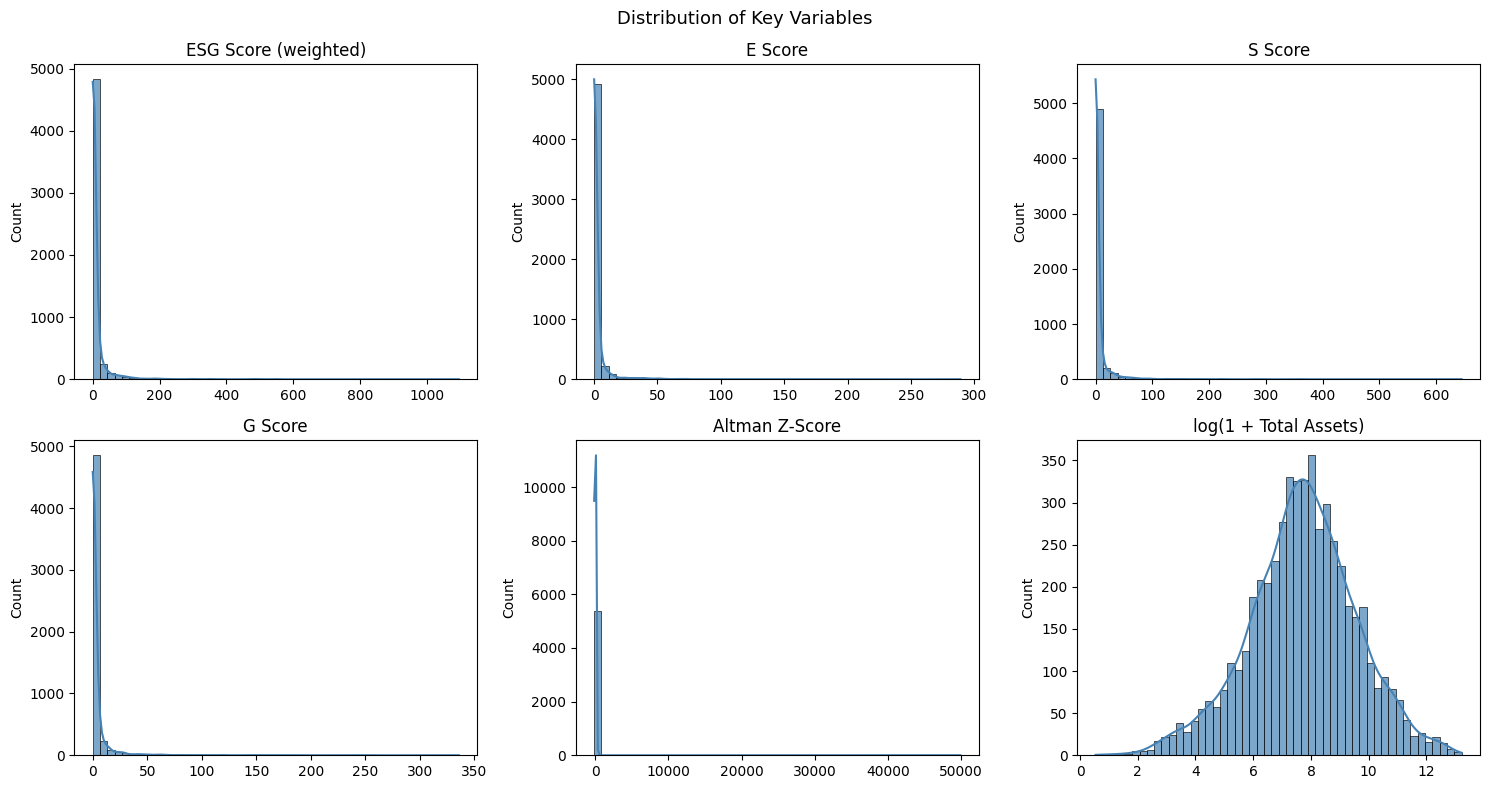

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

plot_vars = [
    ('esg_weight_score', 'ESG Score (weighted)'),
    ('e_weight_score',   'E Score'),
    ('s_weight_score',   'S Score'),
    ('g_weight_score',   'G Score'),
    ('zscore',           'Altman Z-Score'),
    ('at',               'Total Assets'),
]

for ax, (col, label) in zip(axes.flatten(), plot_vars):
    data = df[col].dropna()
    if col == 'at':
        data = np.log1p(data)
        label = 'log(1 + Total Assets)'
    sns.histplot(data, ax=ax, kde=True, bins=50, color='steelblue', alpha=0.7)
    ax.set_title(label)
    ax.set_xlabel('')

plt.suptitle('Distribution of Key Variables', fontsize=13)
plt.tight_layout()
plt.show()

### 3.3 Outlier detection and treatment

We use boxplots to identify outliers, then winsorize at the 1st and 99th percentile to limit their influence on the regression results.

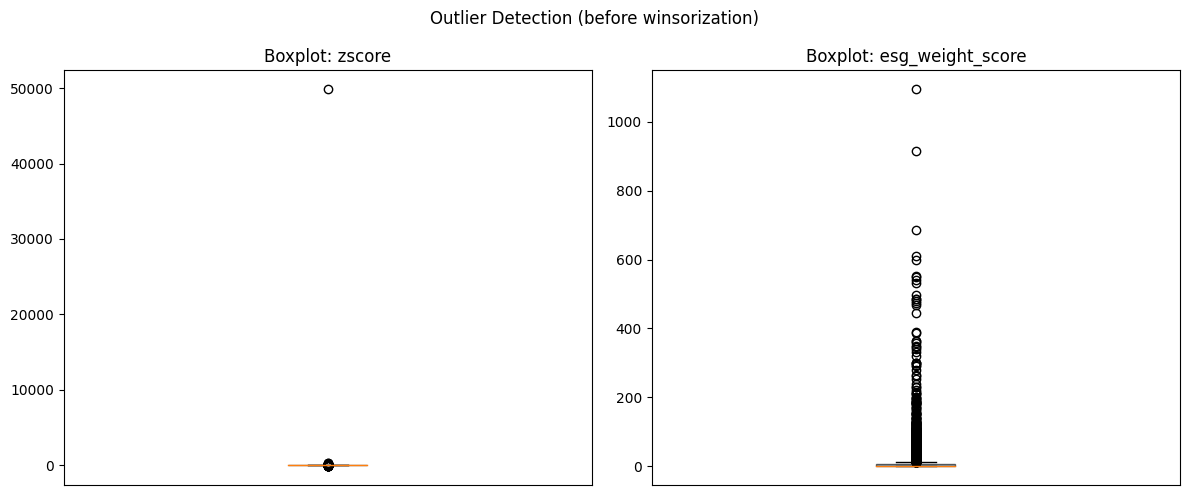

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, ['zscore', 'esg_weight_score']):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(f'Boxplot: {col}')
    ax.set_xticks([])

plt.suptitle('Outlier Detection (before winsorization)')
plt.tight_layout()
plt.show()

In [35]:
# Winsorize at 1st and 99th percentile
def winsorize(series, p=0.01):
    lo, hi = series.quantile(p), series.quantile(1 - p)
    return series.clip(lo, hi)

df['zscore_w']            = winsorize(df['zscore'])
df['esg_weight_score_w']  = winsorize(df['esg_weight_score'])
df['e_weight_score_w']    = winsorize(df['e_weight_score'])
df['s_weight_score_w']    = winsorize(df['s_weight_score'])
df['g_weight_score_w']    = winsorize(df['g_weight_score'])

print('Winsorized variables created.')
print(df[['zscore_w', 'esg_weight_score_w']].describe().round(3))

Winsorized variables created.
       zscore_w  esg_weight_score_w
count  5371.000            5371.000
mean      3.816               9.089
std       5.778              25.914
min     -10.751               0.000
25%       1.481               0.000
50%       2.797               0.000
75%       4.458               5.000
max      36.230             180.600


### 3.4 Descriptive statistics after winsorization

In [36]:
win_cols = ['esg_weight_score_w', 'e_weight_score_w', 's_weight_score_w',
            'g_weight_score_w', 'zscore_w']
df[win_cols].describe().round(3)

,esg_weight_score_w,e_weight_score_w,s_weight_score_w,g_weight_score_w,zscore_w
count,5371.000,5371.000,5371.000,5371.000,5371.000
mean,9.089,1.877,4.362,2.650,3.816
std,25.914,6.653,12.457,8.231,5.778
min,0.000,0.000,0.000,0.000,-10.751
25%,0.000,0.000,0.000,0.000,1.481
50%,0.000,0.000,0.000,0.000,2.797
75%,5.000,0.000,2.000,1.000,4.458
max,180.600,47.000,83.000,58.300,36.230


## 4. Time Trends

### 4.1 Average ESG risk score and Z-score by year

In [37]:
yearly = df.groupby('year').agg(
    esg_weight_score = ('esg_weight_score_w', 'mean'),
    e_weight_score   = ('e_weight_score_w',   'mean'),
    s_weight_score   = ('s_weight_score_w',   'mean'),
    g_weight_score   = ('g_weight_score_w',   'mean'),
    zscore           = ('zscore_w',           'mean'),
    n_firms          = ('primary_isin',       'count')
).reset_index()

print(yearly[['year', 'esg_weight_score', 'zscore', 'n_firms']])

   year  esg_weight_score    zscore  n_firms
0  2018          8.292352  3.983036     1386
1  2019          9.415238  3.689040     1365
2  2020          9.349281  3.388938     1321
3  2021          9.333333  4.207548     1299


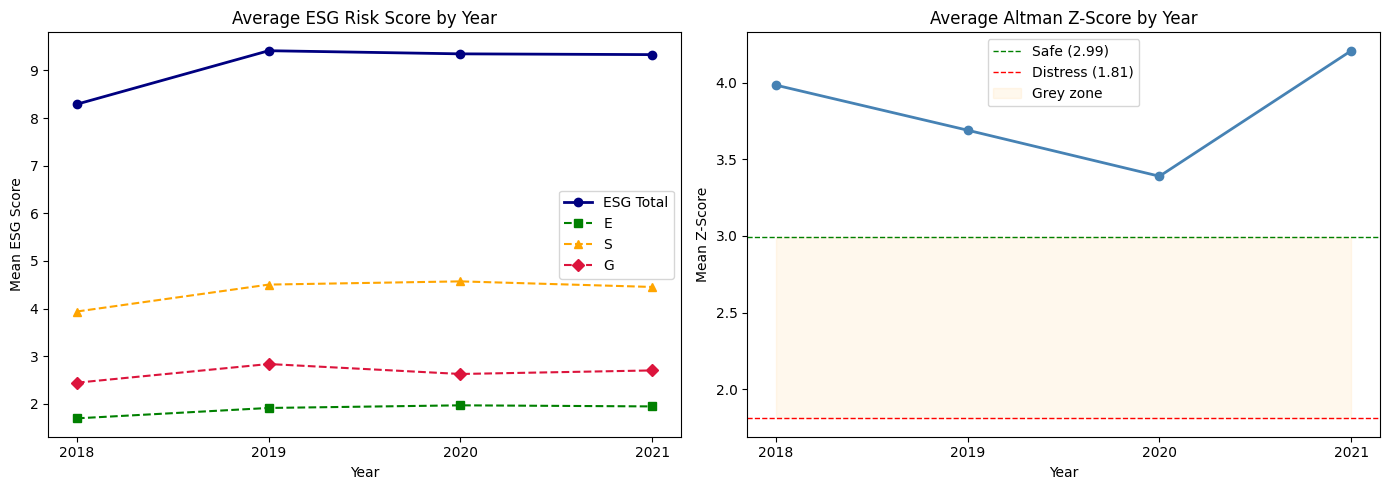

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(yearly['year'], yearly['esg_weight_score'], 'o-', lw=2, label='ESG Total', color='navy')
ax.plot(yearly['year'], yearly['e_weight_score'],   's--', lw=1.5, label='E', color='green')
ax.plot(yearly['year'], yearly['s_weight_score'],   '^--', lw=1.5, label='S', color='orange')
ax.plot(yearly['year'], yearly['g_weight_score'],   'D--', lw=1.5, label='G', color='crimson')
ax.set_title('Average ESG Risk Score by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Mean ESG Score')
ax.legend()
ax.set_xticks(yearly['year'])

ax2 = axes[1]
ax2.plot(yearly['year'], yearly['zscore'], 'o-', lw=2, color='steelblue')
ax2.axhline(2.99, color='green', ls='--', lw=1, label='Safe (2.99)')
ax2.axhline(1.81, color='red',   ls='--', lw=1, label='Distress (1.81)')
ax2.fill_between(yearly['year'], 1.81, 2.99, alpha=0.07, color='orange', label='Grey zone')
ax2.set_title('Average Altman Z-Score by Year')
ax2.set_xlabel('Year')
ax2.set_ylabel('Mean Z-Score')
ax2.legend()
ax2.set_xticks(yearly['year'])

plt.tight_layout()
plt.show()

### 4.2 Proportion of firms in each Z-score zone by year

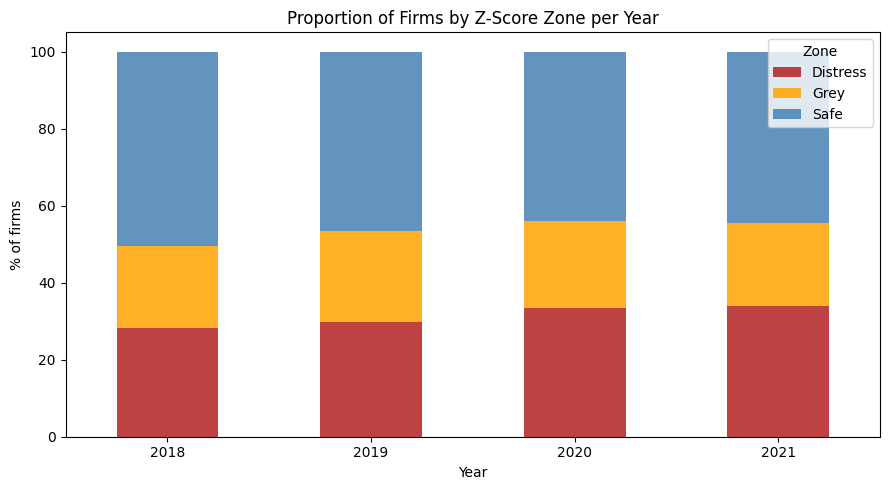

In [39]:
zone_counts = df.groupby(['year', 'zscore_zone']).size().unstack(fill_value=0)
zone_pct = zone_counts.div(zone_counts.sum(axis=1), axis=0) * 100

zone_pct[['Distress', 'Grey', 'Safe']].plot(
    kind='bar', stacked=True, figsize=(9, 5),
    color=['firebrick', 'orange', 'steelblue'], alpha=0.85
)
plt.title('Proportion of Firms by Z-Score Zone per Year')
plt.xlabel('Year')
plt.ylabel('% of firms')
plt.xticks(rotation=0)
plt.legend(title='Zone')
plt.tight_layout()
plt.show()

## 5. Correlation Analysis

### 5.1 Correlation matrix

We use Spearman rank correlation as our primary measure since ESG scores are not normally distributed. Pearson is shown as a reference.

In [40]:
corr_cols   = ['zscore_w', 'esg_weight_score_w', 'e_weight_score_w', 's_weight_score_w', 'g_weight_score_w']
corr_labels = ['Z-score', 'ESG', 'E score', 'S score', 'G score']

spearman_corr = df[corr_cols].corr(method='spearman')
pearson_corr  = df[corr_cols].corr(method='pearson')

# Rename for readability
spearman_corr.columns = corr_labels
spearman_corr.index   = corr_labels
pearson_corr.columns  = corr_labels
pearson_corr.index    = corr_labels

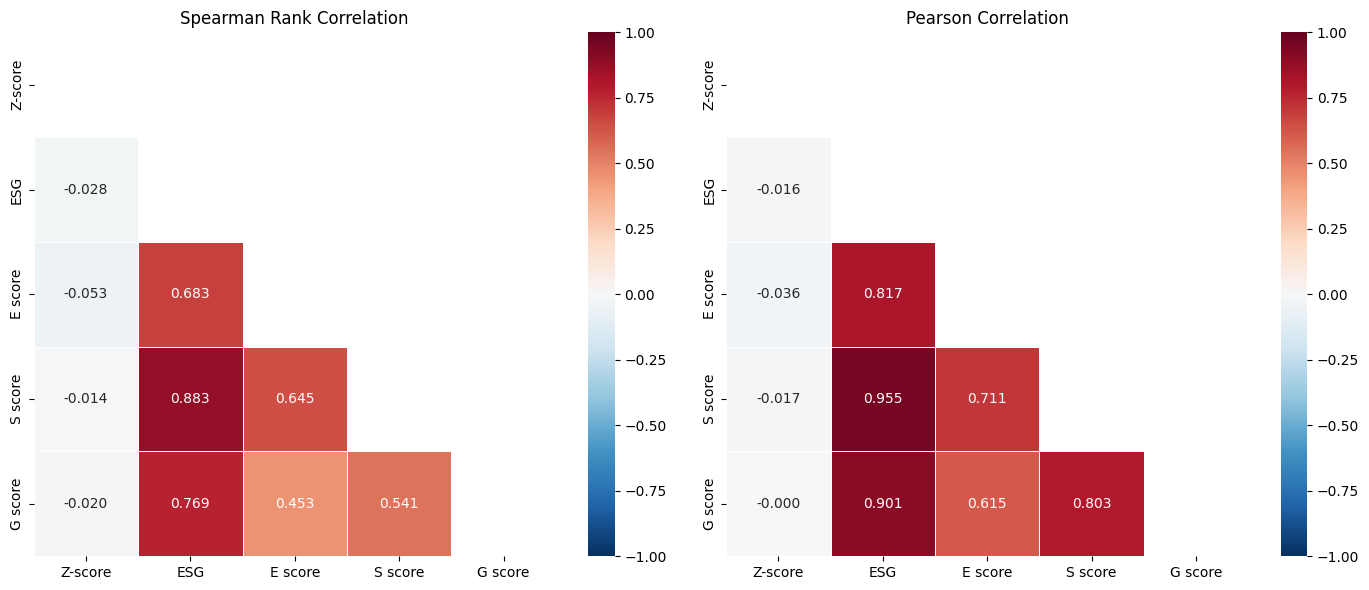

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (corr_mat, title) in zip(axes, [
    (spearman_corr, 'Spearman Rank Correlation'),
    (pearson_corr,  'Pearson Correlation'),
]):
    mask = np.triu(np.ones_like(corr_mat, dtype=bool))
    sns.heatmap(corr_mat, annot=True, fmt='.3f', cmap='RdBu_r',
                vmin=-1, vmax=1, mask=mask, ax=ax, linewidths=0.5)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [42]:
# Statistical tests
print('Spearman correlations with Z-score:')
for col, label in zip(corr_cols[1:], corr_labels[1:]):
    r, p = stats.spearmanr(df['zscore_w'], df[col])
    sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'  Z-score × {label:<12}: rho = {r:+.4f}  p = {p:.4e}  {sig}')

Spearman correlations with Z-score:
  Z-score × ESG         : rho = -0.0277  p = 4.2448e-02  *
  Z-score × E score     : rho = -0.0535  p = 8.8558e-05  ***
  Z-score × S score     : rho = -0.0141  p = 3.0250e-01  
  Z-score × G score     : rho = -0.0196  p = 1.5011e-01  


### 5.2 Scatter plots: Z-score vs ESG scores

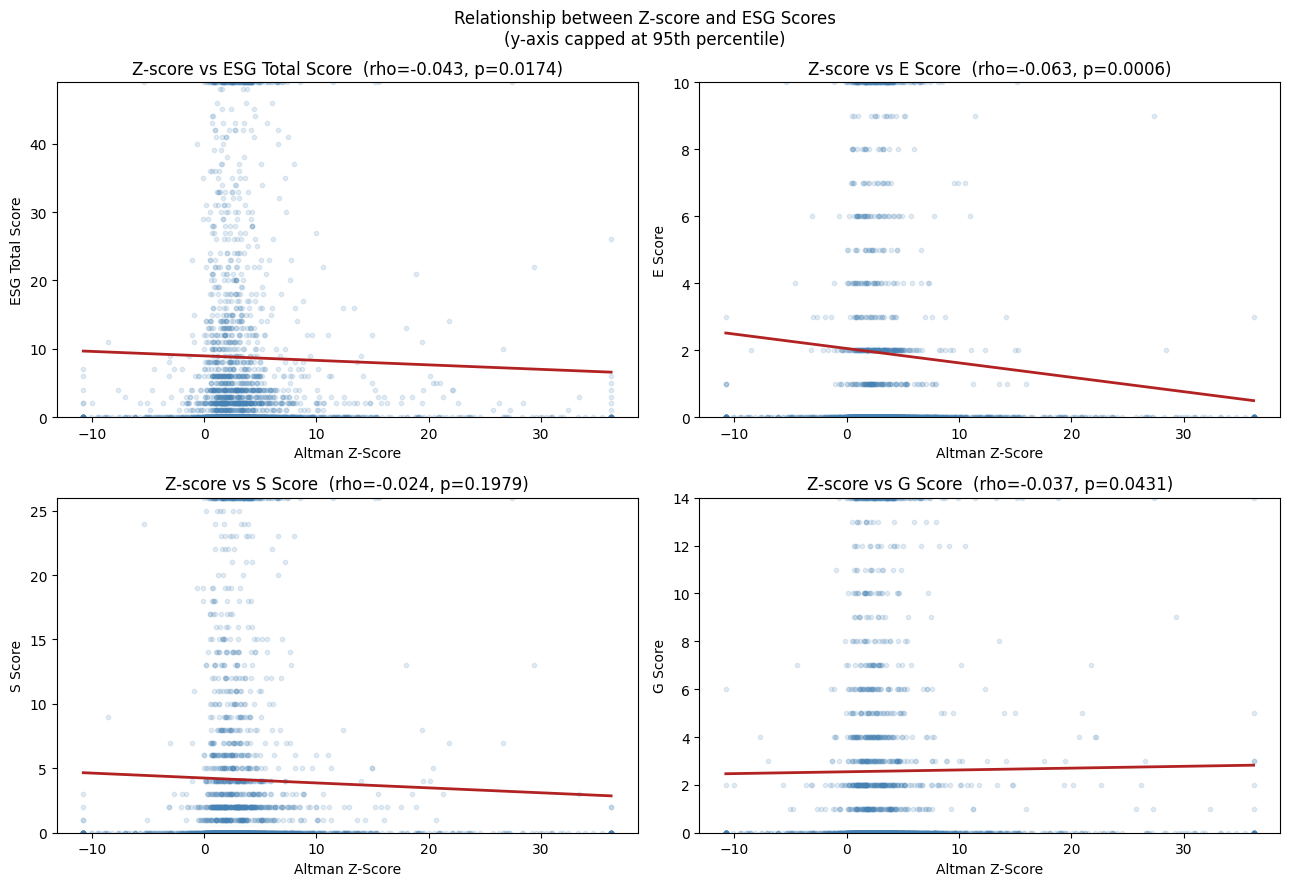

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

pairs = [
    ('zscore_w', 'esg_weight_score_w', 'ESG Total Score'),
    ('zscore_w', 'e_weight_score_w',   'E Score'),
    ('zscore_w', 's_weight_score_w',   'S Score'),
    ('zscore_w', 'g_weight_score_w',   'G Score'),
]

for ax, (x, y, ylabel) in zip(axes.flatten(), pairs):
    sample = df[[x, y]].dropna().sample(min(3000, len(df)), random_state=42)
    y_cap = df[y].quantile(0.95)
    ax.scatter(sample[x], sample[y].clip(upper=y_cap), alpha=0.15, s=10, color='steelblue')
    m, b, r, p, _ = stats.linregress(sample[x], sample[y])
    xline = np.linspace(sample[x].min(), sample[x].max(), 200)
    ax.plot(xline, m * xline + b, color='firebrick', lw=2)
    rho, p_sp = stats.spearmanr(sample[x], sample[y])
    ax.set_xlabel('Altman Z-Score')
    ax.set_ylabel(ylabel)
    ax.set_ylim(bottom=0, top=y_cap)
    ax.set_title(f'Z-score vs {ylabel}  (rho={rho:.3f}, p={p_sp:.4f})')

plt.suptitle('Relationship between Z-score and ESG Scores\n(y-axis capped at 95th percentile)', fontsize=12)
plt.tight_layout()
plt.show()

### 5.3 ESG score by Z-score zone

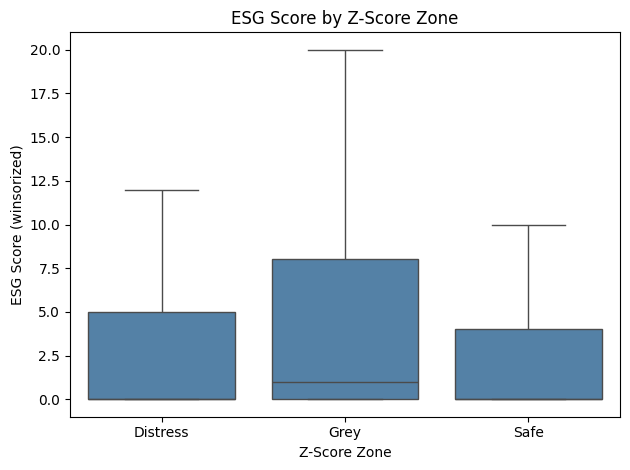


Mean ESG per zone:
                 mean  median  count
zscore_zone                         
Distress     7.556930     0.0   1681
Grey         9.821500     1.0   1200
Safe         9.771245     0.0   2490


In [44]:
order = ['Distress', 'Grey', 'Safe']

sns.boxplot(data=df, x='zscore_zone', y='esg_weight_score_w',
            order=order, color='steelblue', showfliers=False)
plt.title('ESG Score by Z-Score Zone')
plt.xlabel('Z-Score Zone')
plt.ylabel('ESG Score (winsorized)')
plt.tight_layout()
plt.show()

print('\nMean ESG per zone:')
print(df.groupby('zscore_zone')['esg_weight_score_w'].agg(['mean', 'median', 'count']).loc[order])

## 6. Regression Analysis

### 6.1 Baseline OLS: ESG score ~ Z-score

We first estimate a simple OLS model to test whether Z-score is associated with ESG risk score. Robust standard errors (HC3) are used to account for heteroskedasticity.

In [45]:
targets = {
    'ESG Total' : 'esg_weight_score_w',
    'E Score'   : 'e_weight_score_w',
    'S Score'   : 's_weight_score_w',
    'G Score'   : 'g_weight_score_w',
}

results = {}

print('=' * 65)
print(f'{"Dependent":<15} {"β (Z-score)":>12} {"Std Err":>10} {"t-stat":>8} {"p-value":>10} {"R²":>8}')
print('-' * 65)

for name, dep in targets.items():
    model = smf.ols(f'{dep} ~ zscore_w', data=df).fit(cov_type='HC3')
    results[name] = model
    coef  = model.params['zscore_w']
    se    = model.bse['zscore_w']
    t     = model.tvalues['zscore_w']
    pval  = model.pvalues['zscore_w']
    r2    = model.rsquared
    sig   = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
    print(f'{name:<15} {coef:>12.4f} {se:>10.4f} {t:>8.3f} {pval:>10.4f}{sig} {r2:>8.4f}')

print('=' * 65)
print('Significance: *** p<0.001  ** p<0.01  * p<0.05')

Dependent        β (Z-score)    Std Err   t-stat    p-value       R²
-----------------------------------------------------------------
ESG Total            -0.0735     0.0403   -1.824     0.0682   0.0003
E Score              -0.0415     0.0068   -6.092     0.0000***   0.0013
S Score              -0.0377     0.0194   -1.943     0.0520   0.0003
G Score              -0.0004     0.0139   -0.029     0.9772   0.0000
Significance: *** p<0.001  ** p<0.01  * p<0.05


In [46]:
# Full summary for ESG Total
print(results['ESG Total'].summary())

                            OLS Regression Results                            
Dep. Variable:     esg_weight_score_w   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     3.325
Date:                Sun, 12 Apr 2026   Prob (F-statistic):             0.0683
Time:                        23:12:01   Log-Likelihood:                -25101.
No. Observations:                5371   AIC:                         5.021e+04
Df Residuals:                    5369   BIC:                         5.022e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.3698      0.378     24.799      0.0

## 7. Confounding Variables & Extended Regression

**Potential confounders:**
- **Firm size** (`log_assets`): Larger firms face more media scrutiny → more reported incidents
- **Leverage** (`leverage = lt/at`): More indebted firms may cut ESG investment
- **Profitability** (`roa`): More profitable firms have resources to invest in ESG
- **Industry** (`sic` groups): Some sectors are inherently more exposed to ESG risk
- **Year fixed effects**: Macro shocks (e.g. COVID-19 in 2020) affect all firms simultaneously

We add these controls progressively and compare results.

In [47]:
df['log_assets'] = np.log1p(df['at'].clip(lower=0))
df['leverage']   = (df['lt'] / df['at']).clip(-5, 5)
df['roa']        = (df['ebit'] / df['at']).clip(-1, 1)
df['industry']   = (df['sic'] // 1000).astype(str)
df['year_str']   = df['year'].astype(str)

print('Control variables created.')
df[['log_assets', 'leverage', 'roa', 'industry']].describe().round(3)

Control variables created.


,log_assets,leverage,roa
count,5371.000,5371.000,5371.000
mean,7.711,0.615,0.029
std,1.859,0.327,0.185
min,0.539,0.005,-1.000
25%,6.580,0.431,0.010
50%,7.756,0.591,0.063
75%,8.893,0.749,0.109
max,13.221,5.000,0.751


In [48]:
subset = df.dropna(subset=['zscore_w', 'esg_weight_score_w', 'log_assets', 'leverage', 'roa'])

formulas = {
    '(1) Baseline'            : 'esg_weight_score_w ~ zscore_w',
    '(2) + Firm controls'     : 'esg_weight_score_w ~ zscore_w + log_assets + leverage + roa',
    '(3) + Year & Industry FE': 'esg_weight_score_w ~ zscore_w + log_assets + leverage + roa + C(year_str) + C(industry)',
}

models_extended = {}

print('=' * 75)
print(f'{"Model":<28} {"β Z-score":>10} {"SE":>8} {"p-value":>10} {"Adj R²":>9} {"N":>7}')
print('-' * 75)

for label, formula in formulas.items():
    m = smf.ols(formula, data=subset).fit(cov_type='HC3')
    models_extended[label] = m
    coef   = m.params['zscore_w']
    se     = m.bse['zscore_w']
    pval   = m.pvalues['zscore_w']
    adj_r2 = m.rsquared_adj
    n      = int(m.nobs)
    sig    = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
    print(f'{label:<28} {coef:>10.4f} {se:>8.4f} {pval:>10.4f}{sig} {adj_r2:>9.4f} {n:>7}')

print('=' * 75)

Model                         β Z-score       SE    p-value    Adj R²       N
---------------------------------------------------------------------------
(1) Baseline                    -0.0735   0.0403     0.0682    0.0001    5371
(2) + Firm controls              0.2983   0.0490     0.0000***    0.2537    5371
(3) + Year & Industry FE         0.2612   0.0509     0.0000***    0.2636    5353


**Note on sign flip:** The baseline regression shows a negative coefficient (higher Z-score → fewer incidents). But once we control for firm size, the sign reverses. This is because large firms have both higher Z-scores AND more reported ESG incidents (due to higher media visibility). Firm size is a classic confounder here — this is an example of Simpson's Paradox.

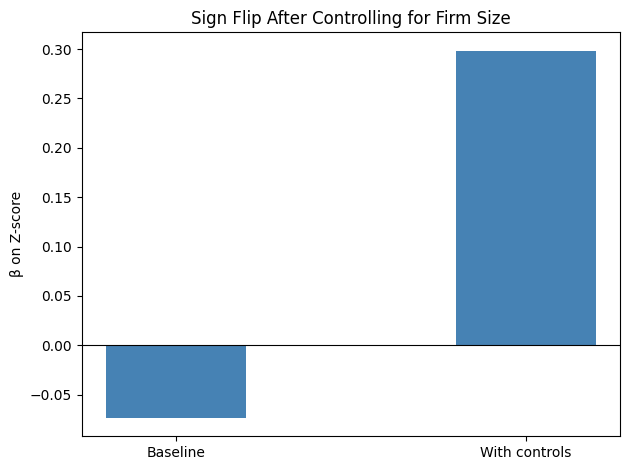

In [49]:
# Visualise the sign flip
scenarios = ['Baseline', 'With controls']
coefs_baseline = [models_extended['(1) Baseline'].params['zscore_w'],
                  models_extended['(2) + Firm controls'].params['zscore_w']]

plt.bar(scenarios, coefs_baseline, color='steelblue', width=0.4)
plt.axhline(0, color='black', lw=0.8)
plt.ylabel('β on Z-score')
plt.title('Sign Flip After Controlling for Firm Size')
plt.tight_layout()
plt.show()

In [50]:
# Same analysis for E, S, G sub-scores with full controls
print('Extended regression by ESG dimension (full controls):')
print('=' * 70)
print(f'{"Dimension":<12} {"β Z-score":>10} {"SE":>8} {"p-value":>10} {"Adj R²":>9}')
print('-' * 70)

for name, dep in targets.items():
    formula = f'{dep} ~ zscore_w + log_assets + leverage + roa + C(year_str) + C(industry)'
    m = smf.ols(formula, data=subset).fit(cov_type='HC3')
    coef   = m.params['zscore_w']
    se     = m.bse['zscore_w']
    pval   = m.pvalues['zscore_w']
    adj_r2 = m.rsquared_adj
    sig    = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
    print(f'{name:<12} {coef:>10.4f} {se:>8.4f} {pval:>10.4f} {sig:<5} {adj_r2:>9.4f}')

print('=' * 70)

Extended regression by ESG dimension (full controls):
Dimension     β Z-score       SE    p-value    Adj R²
----------------------------------------------------------------------
ESG Total        0.2612   0.0509     0.0000 ***      0.2636
E Score          0.0206   0.0103     0.0458 *        0.1936
S Score          0.1318   0.0238     0.0000 ***      0.2519
G Score          0.0960   0.0173     0.0000 ***      0.2311


## 8. Year-by-Year Analysis

We run the same regression separately for each year to check whether the relationship between Z-score and ESG risk score changes over time. We keep the firm controls and industry fixed effects in each year-level regression.

In [51]:
yearly_results = []

for year in sorted(df['year'].unique()):
    sub = df[df['year'] == year].dropna(
        subset=['zscore_w', 'esg_weight_score_w', 'log_assets', 'leverage', 'roa']
    )
    if len(sub) < 30:
        continue
    m = smf.ols(
        'esg_weight_score_w ~ zscore_w + log_assets + leverage + roa + C(industry)',
        data=sub
    ).fit(cov_type='HC3')
    coef = m.params['zscore_w']
    pval = m.pvalues['zscore_w']
    ci_lo, ci_hi = m.conf_int().loc['zscore_w']
    yearly_results.append({
        'year': year, 'coef': coef, 'pval': pval,
        'ci_lo': ci_lo, 'ci_hi': ci_hi, 'n': int(m.nobs)
    })

yr_df = pd.DataFrame(yearly_results)
print(yr_df.to_string(index=False))

 year     coef     pval     ci_lo    ci_hi    n
 2018 0.287779 0.014724  0.056531 0.519026 1382
 2019 0.316833 0.001297  0.123778 0.509888 1361
 2020 0.146318 0.147966 -0.051904 0.344540 1316
 2021 0.275431 0.003100  0.092907 0.457956 1294


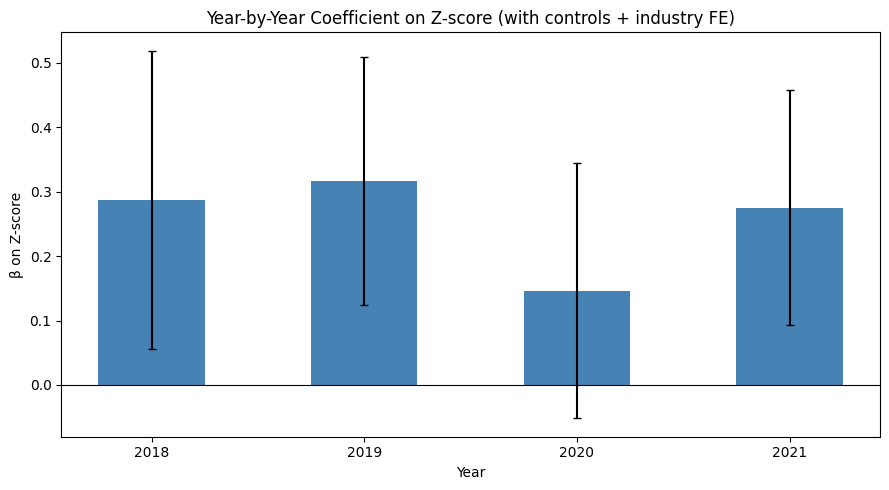

In [52]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(yr_df['year'], yr_df['coef'], color='steelblue', width=0.5)
ax.errorbar(yr_df['year'], yr_df['coef'],
            yerr=[yr_df['coef'] - yr_df['ci_lo'], yr_df['ci_hi'] - yr_df['coef']],
            fmt='none', color='black', capsize=3)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('β on Z-score')
ax.set_title('Year-by-Year Coefficient on Z-score (with controls + industry FE)')
ax.set_xticks(yr_df['year'])
plt.tight_layout()
plt.show()

## 9. Panel Data: Fixed Effects Model

Fixed effects (within-firm estimator) removes all time-invariant firm characteristics (e.g. industry, management quality) and isolates the **cross-sectional** effect of Z-score variation.

We use firm + year fixed effects (two-way FE) and compare with pooled OLS.

In [53]:
try:
    from linearmodels.panel import PanelOLS, PooledOLS
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'linearmodels', '-q'])
    from linearmodels.panel import PanelOLS, PooledOLS

In [54]:
# Prepare panel dataset
panel_df = df[['primary_isin', 'year', 'esg_weight_score_w',
               'e_weight_score_w', 's_weight_score_w', 'g_weight_score_w',
               'zscore_w', 'log_assets', 'leverage', 'roa']].dropna().copy()

# Drop firms observed only once (FE cannot be estimated for singletons)
panel_df = panel_df[
    panel_df.groupby('primary_isin')['year'].transform('count') > 1
]

panel_df = panel_df.set_index(['primary_isin', 'year'])
print(f'Panel observations: {len(panel_df):,}')
print(f'Unique firms      : {panel_df.index.get_level_values(0).nunique():,}')

Panel observations: 5,253
Unique firms      : 1,402


In [55]:
# Pooled OLS
pooled_res = PooledOLS.from_formula(
    'esg_weight_score_w ~ zscore_w + log_assets + leverage + roa + 1',
    data=panel_df
).fit(cov_type='clustered', cluster_entity=True)

# Two-way Fixed Effects (firm + year)
fe_res = PanelOLS.from_formula(
    'esg_weight_score_w ~ zscore_w + log_assets + leverage + roa + EntityEffects + TimeEffects',
    data=panel_df
).fit(cov_type='clustered', cluster_entity=True)

In [56]:
print('=== Pooled OLS ===')
print(pooled_res.summary.tables[1])
print('\n=== Two-Way Fixed Effects (Firm + Year FE) ===')
print(fe_res.summary.tables[1])

=== Pooled OLS ===
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept     -53.589     5.0142    -10.687     0.0000     -63.419     -43.759
zscore_w       0.2993     0.0863     3.4664     0.0005      0.1300      0.4686
log_assets     7.8705     0.6941     11.340     0.0000      6.5098      9.2311
leverage       2.5092     1.5651     1.6032     0.1089     -0.5590      5.5773
roa           -24.398     3.1702    -7.6959     0.0000     -30.613     -18.183

=== Two-Way Fixed Effects (Firm + Year FE) ===
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
zscore_w       0.0012     0.0280     0.0412     0.9671     -0.05

In [57]:
# Side-by-side comparison
print('\n' + '=' * 65)
print('Model comparison: β on Z-Score')
print('=' * 65)
for label, res in [('Pooled OLS', pooled_res), ('Two-Way FE (Firm + Year)', fe_res)]:
    coef = res.params['zscore_w']
    pval = res.pvalues['zscore_w']
    sig  = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
    print(f'{label:<30}  β = {coef:.4f}   p = {pval:.4f}  {sig}')
print('=' * 65)


Model comparison: β on Z-Score
Pooled OLS                      β = 0.2993   p = 0.0005  ***
Two-Way FE (Firm + Year)        β = 0.0012   p = 0.9671  n.s.


**Interpretation of the fixed effects result:**

When we use firm fixed effects (within estimator), the coefficient on Z-score becomes very small and insignificant. This tells us that the relationship we observe is **cross-sectional** — it exists *between* firms, but **not within** a given firm over time.

In other words: when a firm's Z-score changes from one year to the next, its ESG incident count does not systematically change. The cross-sectional pattern is likely driven by stable firm characteristics (size, management quality, industry exposure) that simultaneously determine both financial health and ESG visibility.

In [58]:
# FE results for E, S, G sub-scores
print('Two-Way FE by ESG dimension:')
print('=' * 60)
for name, dep in targets.items():
    sub_panel = (
        df[['primary_isin', 'year', dep, 'zscore_w', 'log_assets', 'leverage', 'roa']]
        .dropna().copy()
    )
    sub_panel = sub_panel[
        sub_panel.groupby('primary_isin')['year'].transform('count') > 1
    ].set_index(['primary_isin', 'year'])
    m = PanelOLS.from_formula(
        f'{dep} ~ zscore_w + log_assets + leverage + roa + EntityEffects + TimeEffects',
        data=sub_panel
    ).fit(cov_type='clustered', cluster_entity=True)
    coef = m.params['zscore_w']
    pval = m.pvalues['zscore_w']
    sig  = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
    print(f'{name:<12}  β = {coef:+.4f}   p = {pval:.4f}  {sig}')
print('=' * 60)

Two-Way FE by ESG dimension:
ESG Total     β = +0.0012   p = 0.9671  n.s.
E Score       β = +0.0119   p = 0.3829  n.s.
S Score       β = +0.0014   p = 0.9242  n.s.
G Score       β = -0.0080   p = 0.4307  n.s.


## 10. Export Final Dataset

In [59]:
export_cols = [
    'primary_isin', 'conm', 'year', 'zscore', 'zscore_zone',
    'n_incidents', 'esg_weight_score_w', 'e_weight_score_w',
    's_weight_score_w', 'g_weight_score_w',
    'log_assets', 'leverage', 'roa', 'sic', 'industry'
]
df[export_cols].to_csv('final_dataset.csv', index=False)
print(f'Exported final_dataset.csv — shape: {df[export_cols].shape}')

Exported final_dataset.csv — shape: (5371, 15)
